## Домашка 4

#### *«Вы видите, но не наблюдаете.» — Шерлок*

Эта домашка про мониторинг метрик и детекцию аномалий. За неё можно получить максимум 12 баллов. На решение отводится **14 календарных дней** с момента выдачи. Обратите внимание, что **дедлайны на курсе сразу жёсткие**, а значит отправка решений после них запрещена.
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета. 
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в [ведомости](https://docs.google.com/spreadsheets/d/13lHNf6xU6tZhqzVMAb8sV3RgyyDatepwo7FJ6FhZ0vY/edit?usp=sharing) на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_4). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. В процессе решения вы будете получать ответы на список вопросов, собранный в Яндекс-Формах. Впишите в него ответы.
6. В ту же форму продублируйте ссылку на PR (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса). Вопросы в Формах с автопроверкой, однако сданный тест, к которому не была приложена ссылка на ноутбук с расчетом ответов, получает 0 баллов.

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3. 

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.


Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_4_data.zip)

In [76]:
import math
import random
from datetime import datetime
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt
from scipy.stats import t
from statsmodels.tsa.seasonal import STL  

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

### Warm up

#### 1. Сопоставьте метод детекции аномалий с контекстом применения — 2 балла

a) Онлайн-мониторинг   
b) Батч-анализ по историческим данным  

1. Правило 3σ.
2. Generalized ESD
3. Grubbs test
4. CUMSUM
5. EWMA
6. STL-разложение + Generalized ESD

---

In [77]:
answer_task_1 = {
    1: 'a',  # Правило 3σ → Онлайн (простой, скользящее окно)
    2: 'b',  # Generalized ESD → Батч (итеративный, нужен весь датасет)
    3: 'b',  # Grubbs test → Батч (статтест, полная выборка)
    4: 'a',  # CUMSUM → Онлайн (кумулятивная сумма)
    5: 'a',  # EWMA → Онлайн (экспоненциальное сглаживание)
    6: 'b'   # STL + ESD → Батч (декомпозиция требует историю)
}

answer_task_1

{1: 'a', 2: 'b', 3: 'b', 4: 'a', 5: 'a', 6: 'b'}

### Case Study. Система мониторинга метрик для Ecom-приложения 🥪

**Легенда**  
Вы работаете продуктовым аналитиком в ecom-приложении доставки FMCG-товаров. Компания — развивающийся стартап, в котором еще не выстроена система мониторинга метрик.   

Вам поручили провести исследование подходов к детекции аномалий на исторических данных и выбрать методологии, которые будет применять ваша компания для онлайн-мониторинга и ретроспективного анализа.

In [78]:
data = pd.read_csv('hw_4_fmcg.csv')

In [79]:

data['date'] = pd.to_datetime(data['date'])

In [80]:

data.head()

,date,items_sold,gmv,avg_item_price
0,2023-01-01,2907,14944.41,5.140836
1,2023-01-02,3030,16065.13,5.302023
2,2023-01-03,3070,17170.30,5.592932
3,2023-01-04,2708,14367.19,5.305462
4,2023-01-05,3177,16918.53,5.325316


Описание данных:

- date — дата, на которую агрегированы данные
- items_sold — число проданных в день товаров
- gmv – GMV проданных в день товаров
- avg_item_price — средняя цена проданных в день товаров

#### 2. Правило 3σ — 2 балла

1) Реализуйте правило 3σ для каждой метрики:
- gmv;
- items_sold;
- avg_item_price.

Расчет производите на всем датасете. В этом пункте вы имитируете онлайн-мониторинг, поэтому проверка проводится для каждой даты, а границы контроля рассчитываются за последние 28 дней до самой даты. 

2) Постройте графики: метрика + границы контроля + выделенные аномалии.

*Советую обернуть правило для расчета 3σ в функцию, она пригодится на следующем шаге.*

**Внимание: Тут и в дальнейшем для визуализации и ответа на тестовые вопросы формы используйте только данные ЗА МАЙ.**

In [81]:
def detect_anomalies_3sigma(series, window_size=28):
    
    rolling_mean = series.rolling(window=window_size).mean().shift(1)
    rolling_std = series.rolling(window=window_size).std().shift(1)
    
    
    result = pd.DataFrame({
        'value': series.values,
        'mean': rolling_mean,
        'std': rolling_std,
        'upper_bound': rolling_mean + 3 * rolling_std,
        'lower_bound': rolling_mean - 3 * rolling_std
    }, index=series.index)
    
    
    result['is_anomaly'] = (
        (series > result['upper_bound']) | 
        (series < result['lower_bound'])
    )
    
    return result

In [82]:

def plot_anomalies(df_result, metric_name, date_col, may_only=True):
    """Построение графика метрики с границами контроля и аномалиями."""
    if may_only:
        mask = (date_col >= '2023-05-01') & (date_col <= '2023-05-31')
        plot_data = df_result[mask].copy()
        plot_dates = date_col[mask]
    else:
        plot_data = df_result.copy()
        plot_dates = date_col
    
    plt.figure(figsize=(14, 6))
    plt.plot(plot_dates, plot_data['value'], label=metric_name, 
             color='blue', linewidth=2)
    plt.plot(plot_dates, plot_data['upper_bound'], '--', 
             label='Upper bound (μ + 3σ)', color='red', alpha=0.7)
    plt.plot(plot_dates, plot_data['lower_bound'], '--', 
             label='Lower bound (μ - 3σ)', color='red', alpha=0.7)
    
    anomalies = plot_data[plot_data['is_anomaly']]
    if len(anomalies) > 0:
        plt.scatter(plot_dates[plot_data['is_anomaly']], anomalies['value'],
                   color='red', s=100, zorder=5, 
                   label=f'Anomalies ({len(anomalies)})')
    
    plt.xlabel('Date')
    plt.ylabel(metric_name)
    plt.title(f'3σ Anomaly Detection: {metric_name} (May 2023)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

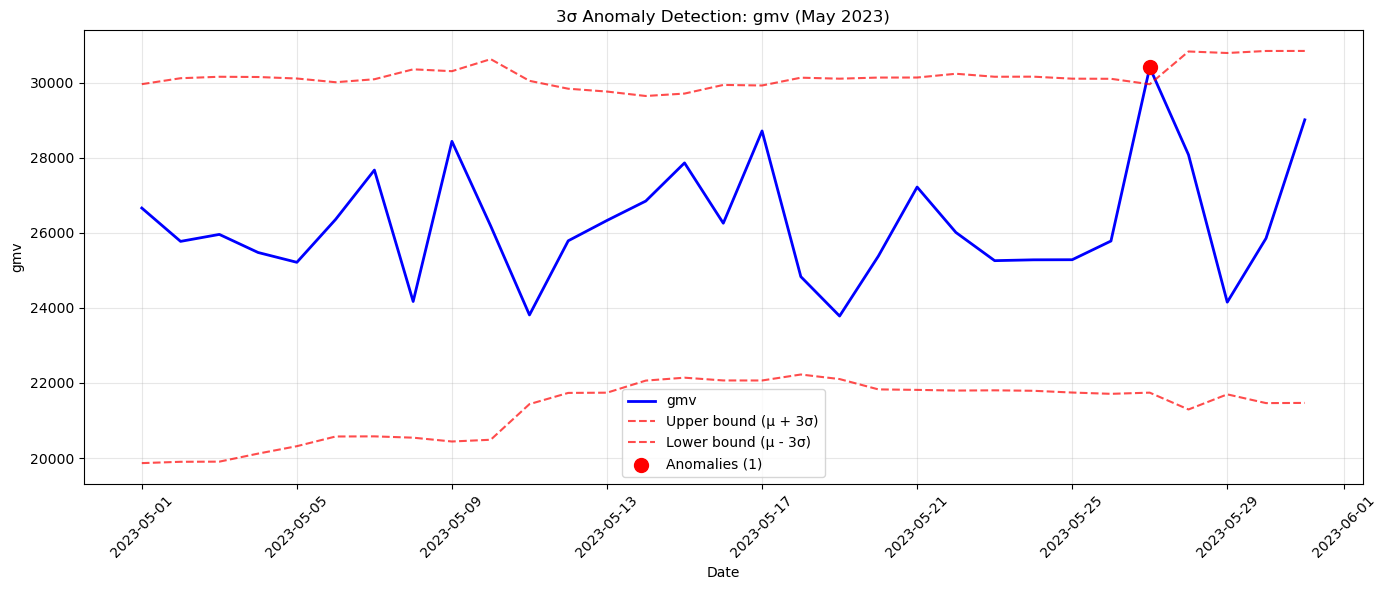

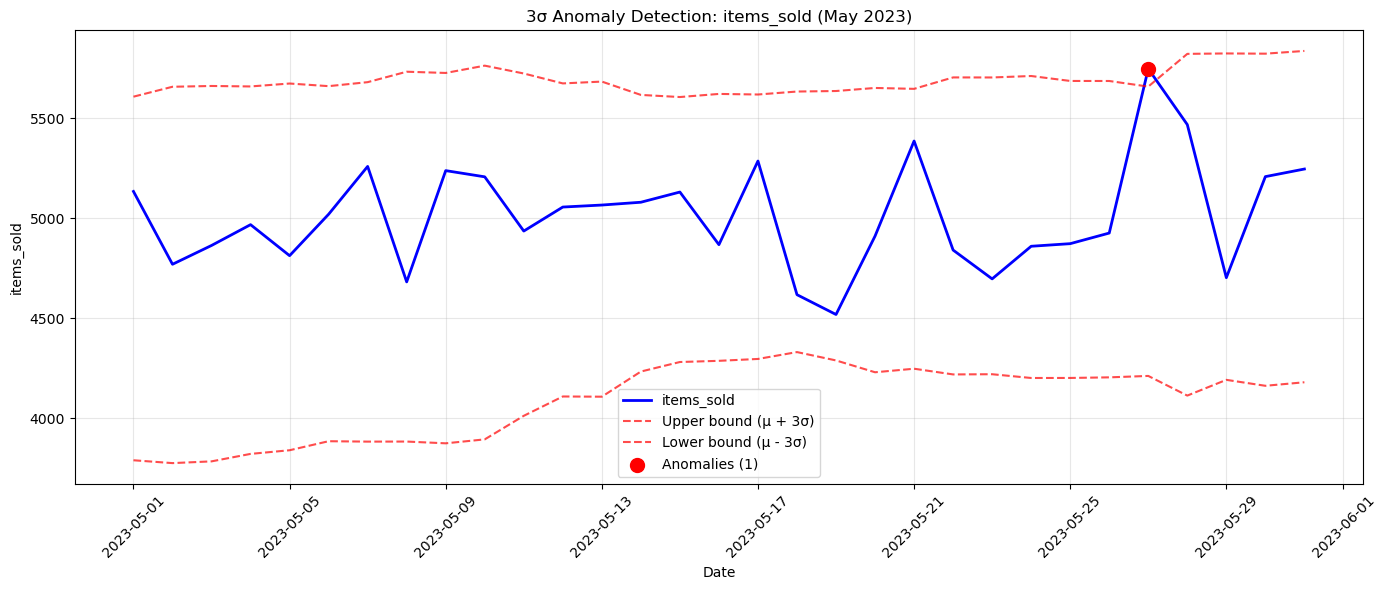

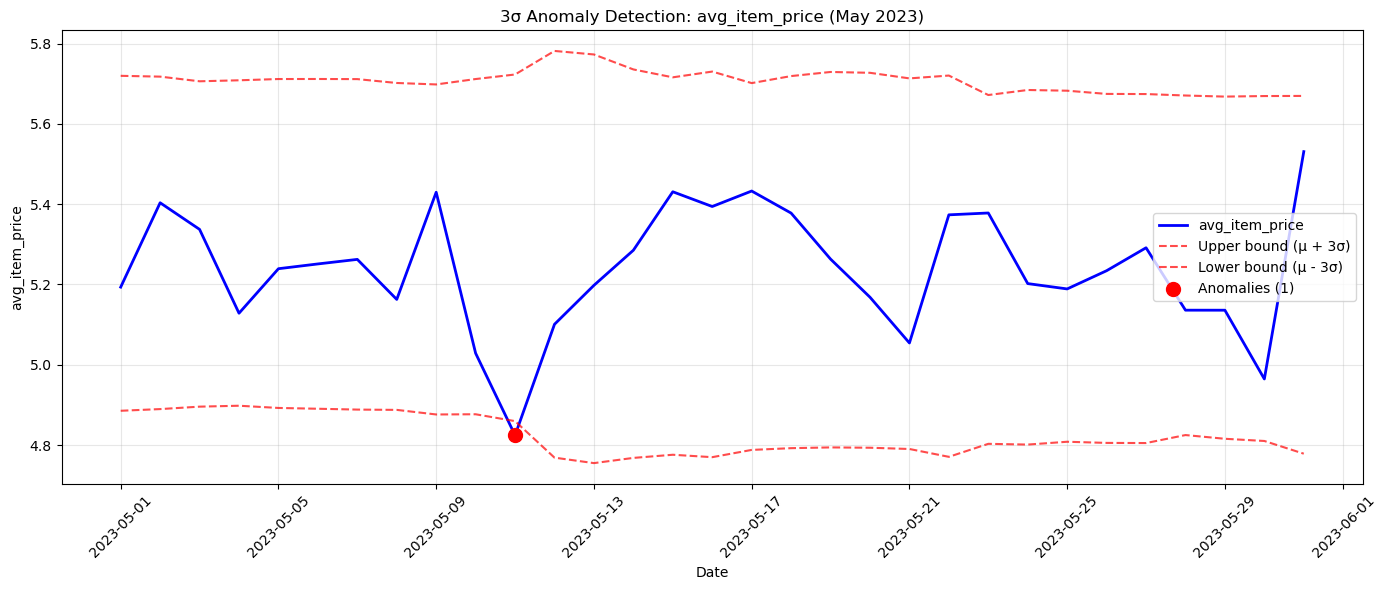

In [ ]:

metrics = ['gmv', 'items_sold', 'avg_item_price']
results_3sigma = {}

for metric in metrics:
    results_3sigma[metric] = detect_anomalies_3sigma(data[metric])
    plot_anomalies(results_3sigma[metric], metric, data['date'])

In [84]:

may_mask = (data['date'] >= '2023-05-01') & (data['date'] <= '2023-05-31')
items_sold_may = results_3sigma['items_sold'][may_mask]
anomalies_items_sold = items_sold_may[items_sold_may['is_anomaly']]

answer_task_2 = None
if len(anomalies_items_sold) > 0:
    answer_task_2 = int(anomalies_items_sold['value'].iloc[0])
    
answer_task_2

5747

**Задание**: введите число, являющееся аномальным значением метрики items_sold.


Правило 3σ поймало выбросы: 27 мая (gmv, items_sold) и 11 мая (avg_item_price — резкое падение цены). 

---

#### 3. Дельта-ряды — 2 балла

1) Рассчитайте дельты значений текущего дня с предыдущим для каждой метрики, затем примените к полученным дельтам правило 3σ:
- gmv;
- items_sold;
- avg_item_price.

Расчет производите на всем датасете. В этом пункте вы имитируете онлайн-мониторинг, поэтому проверка проводится для каждой даты, а границы контроля рассчитываются за последние 28 дней до самой даты. 

2) Постройте графики: дельты метрики + границы контроля + выделенные аномалии.

In [85]:
# Функция визуализации дельт с аномалиями
def plot_delta_anomalies(df_result, metric_name, date_col, may_only=True):
    """Построение графика дельт метрики с границами контроля."""
    mask = (date_col >= '2023-05-01') & (date_col <= '2023-05-31')
    plot_data = df_result[mask].copy() if may_only else df_result.copy()
    plot_dates = date_col[mask] if may_only else date_col
    
    plt.figure(figsize=(14, 6))
    plt.plot(plot_dates, plot_data['value'], 
             label=f'Δ {metric_name}', color='blue', linewidth=2)
    plt.plot(plot_dates, plot_data['upper_bound'], '--', 
             label='Upper (μ + 3σ)', color='red', alpha=0.7)
    plt.plot(plot_dates, plot_data['lower_bound'], '--', 
             label='Lower (μ - 3σ)', color='red', alpha=0.7)
    plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=1)
    
    anomalies = plot_data[plot_data['is_anomaly']]
    if len(anomalies) > 0:
        plt.scatter(plot_dates[plot_data['is_anomaly']], anomalies['value'],
                   color='red', s=100, zorder=5, 
                   label=f'Anomalies ({len(anomalies)})')
    
    plt.xlabel('Date')
    plt.ylabel(f'Δ {metric_name}')
    plt.title(f'Delta Anomaly Detection: {metric_name} (May 2023)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

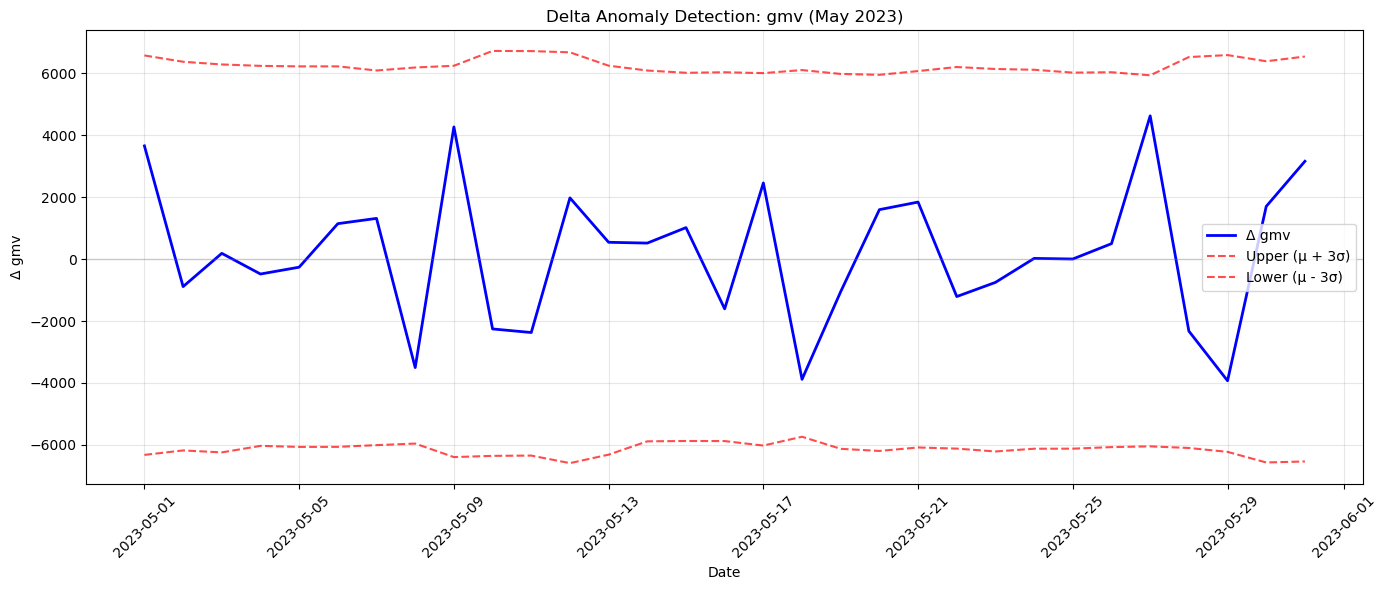

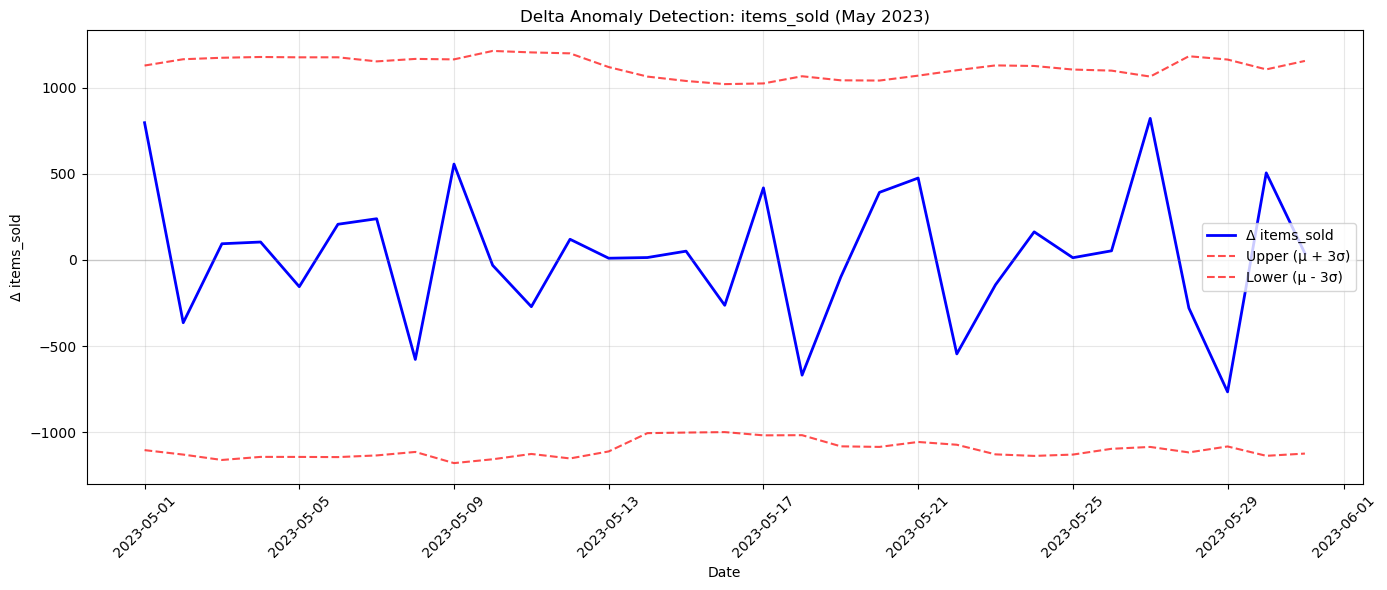

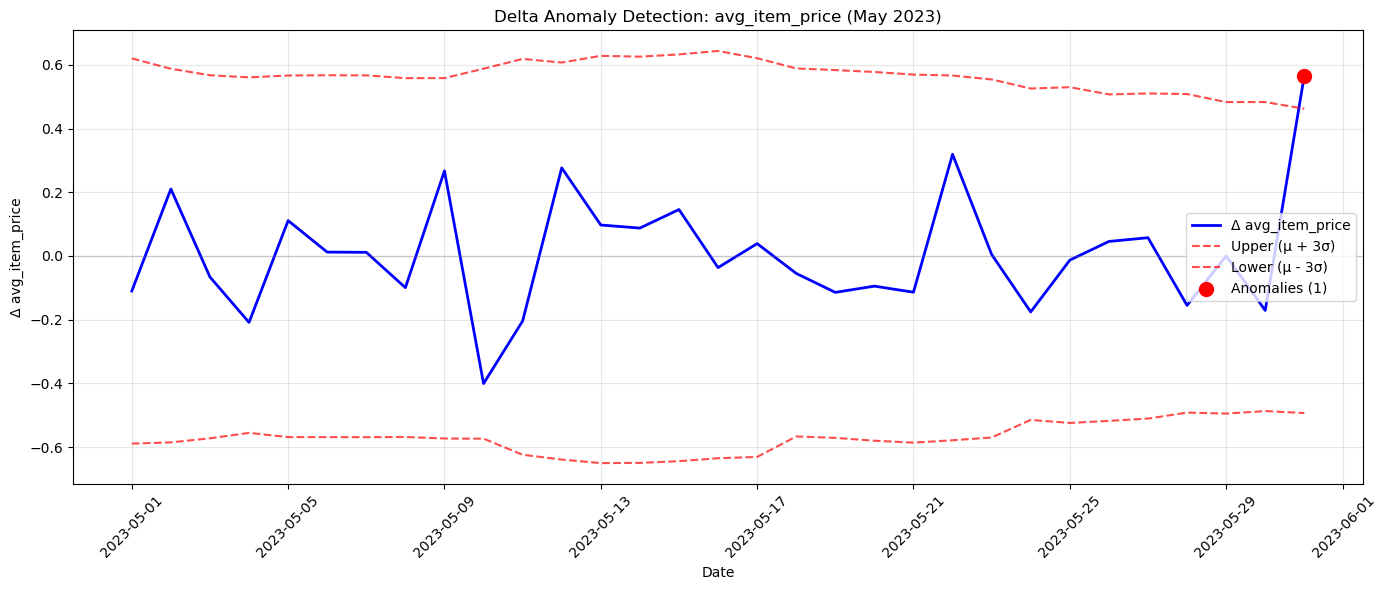

In [86]:
# Расчет дельт и применение 3σ
delta_data = pd.DataFrame({'date': data['date']})

for metric in metrics:
    delta_data[f'delta_{metric}'] = data[metric].diff()

results_delta_3sigma = {}

for metric in metrics:
    results_delta_3sigma[metric] = detect_anomalies_3sigma(
        delta_data[f'delta_{metric}']
    )
    plot_delta_anomalies(
        results_delta_3sigma[metric], metric, delta_data['date']
    )

In [87]:
# Поиск аномальной дельты avg_item_price за май для ответа
may_mask = (delta_data['date'] >= '2023-05-01') & (
    delta_data['date'] <= '2023-05-31'
)
delta_avg_price_may = results_delta_3sigma['avg_item_price'][may_mask]
anomalies_delta_price = delta_avg_price_may[delta_avg_price_may['is_anomaly']]

answer_task_3 = None
if len(anomalies_delta_price) > 0:
    answer_task_3 = round(anomalies_delta_price['value'].iloc[0], 2)
    
answer_task_3

0.57

**Задание**: введите аномальное значение дельты avg_item_price, значение округлите до сотых.

Дельты нашли аномалию 31 мая (avg_item_price +0.57) .diff() убирает тренд одной строкой. Теперь ловим не абсолютные значения, а резкие изменения.

---

#### 4. Generalized ESD — 2 балла

1) Реализуйте [Generalized ESD](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h3.htm). Обратите внимание, с какими данными работает метод — онлайн или батч? Учтите это в реализации.
2) Найдите аномалии для дельт каждой метрики ЗА МАЙ (используйте данные, полученные на прошлом шаге):
- gmv;
- items_sold;
- avg_item_price.
3) Сравните результаты с правилом 3σ на дельтах: разошлись ли методы?

*Советую обернуть Generalized ESD в функцию, она пригодится на следующем шаге.*

In [88]:
# Реализация Generalized ESD теста
def generalized_esd(series, max_anomalies=10, alpha=0.05):
    
    data = series.dropna().copy()
    if len(data) < 3:
        return []
    
    anomaly_indices = []
    
    for i in range(max_anomalies):
        if len(data) < 3:
            break
        
        mean_val, std_val = data.mean(), data.std()
        if std_val == 0:
            break
        
       
        deviations = np.abs(data - mean_val)
        max_idx = deviations.idxmax()
        R_i = deviations.max() / std_val
        
        
        n = len(data)
        p = 1 - alpha / (2 * (n - i))
        df = n - i - 2
        
        if df <= 0:
            break
        
        t_crit = t.ppf(p, df)
        lambda_crit = ((n - i - 1) * t_crit / 
                      np.sqrt((n - i - 2 + t_crit**2) * (n - i)))
        
        if R_i > lambda_crit:
            anomaly_indices.append(max_idx)
            data = data.drop(max_idx)
        else:
            break
    
    return anomaly_indices

In [89]:
# Применение ESD к дельтам метрик за май
may_mask = (delta_data['date'] >= '2023-05-01') & (
    delta_data['date'] <= '2023-05-31'
)
results_esd = {}

for metric in metrics:
    delta_series_may = delta_data.loc[may_mask, f'delta_{metric}']
    results_esd[metric] = generalized_esd(delta_series_may, max_anomalies=10)

In [90]:
# Сравнение 3σ vs ESD
comparison_results = []

for metric in metrics:
    delta_may_3sigma = results_delta_3sigma[metric][may_mask]
    indices_3sigma = set(delta_may_3sigma[delta_may_3sigma['is_anomaly']].index)
    indices_esd = set(results_esd[metric])
    
    comparison_results.append({
        'metric': metric,
        '3sigma_count': len(indices_3sigma),
        'esd_count': len(indices_esd),
        'overlap': len(indices_3sigma & indices_esd),
        'only_3sigma': len(indices_3sigma - indices_esd),
        'only_esd': len(indices_esd - indices_3sigma)
    })

pd.DataFrame(comparison_results)

,metric,3sigma_count,esd_count,overlap,only_3sigma,only_esd
0,gmv,0,0,0,0,0
1,items_sold,0,0,0,0,0
2,avg_item_price,1,1,1,0,0


In [91]:

answer_task_4 = None
if len(results_esd['avg_item_price']) > 0:
    anomaly_idx = results_esd['avg_item_price'][0]
    answer_task_4 = delta_data.loc[anomaly_idx, 'date'].strftime('%Y-%m-%d')
    
answer_task_4

'2023-05-31'

**Задание**: для какой даты дельта avg_item_price является аномалией по методу Generalized ESD? Введите дату в фоммате YYYY-MM-DD

Generalized ESD нашел  аномалию — 31 мая (avg_item_price). Полное совпадение с 3σ в таблице. Батч-метод — нужен весь май сразу. 

---

#### 5. STL-разложение — 2 балла

1) Для каждой метрики выполните STL-разложение с недельной сезонностью (7 дней) на данных всего датасета:
- gmv;
- items_sold;
- avg_item_price.

Используйте STL из библиотеки statsmodels (уже есть в импортах).
  
2) Для каждой метрики визуализируйте компоненты: тренд, сезонность, остатки (на всем датасете).

4) На остатках примените Generalized ESD, можете использовать функцию из прошлого шага. Это упражнение проделываем только на данных ЗА МАЙ.

5) Подумайте, для каждой ли метрики имеет смысл использовать STL, везде ли визуально присутствуют тренд и недельная сезонность?

In [92]:
# Функция для STL-разложения
def perform_stl(series, period=7, seasonal=13):
    stl = STL(series, period=period, seasonal=seasonal)
    return stl.fit()

In [93]:
# Функция визуализации STL компонент
def plot_stl(stl_result, metric_name, date_col):
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    
    components = [
        (stl_result.observed, 'Observed', 'blue'),
        (stl_result.trend, 'Trend', 'green'),
        (stl_result.seasonal, 'Seasonal', 'orange'),
        (stl_result.resid, 'Residual', 'red')
    ]
    
    for ax, (data, label, color) in zip(axes, components):
        ax.plot(date_col, data, color=color, alpha=0.8)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
    
    axes[0].set_title(f'STL Decomposition: {metric_name}')
    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

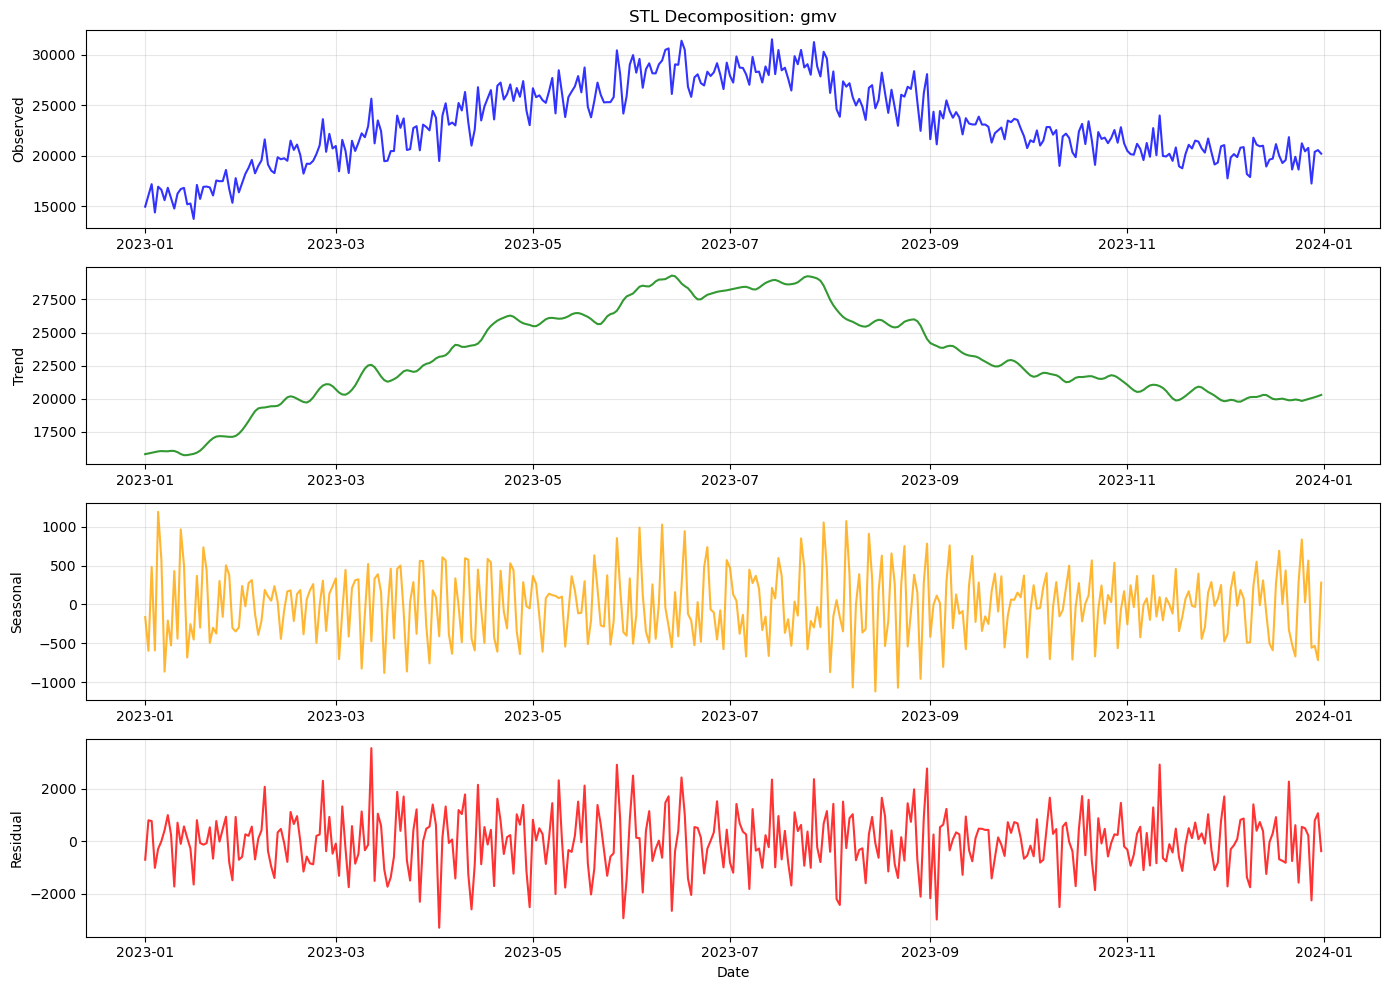

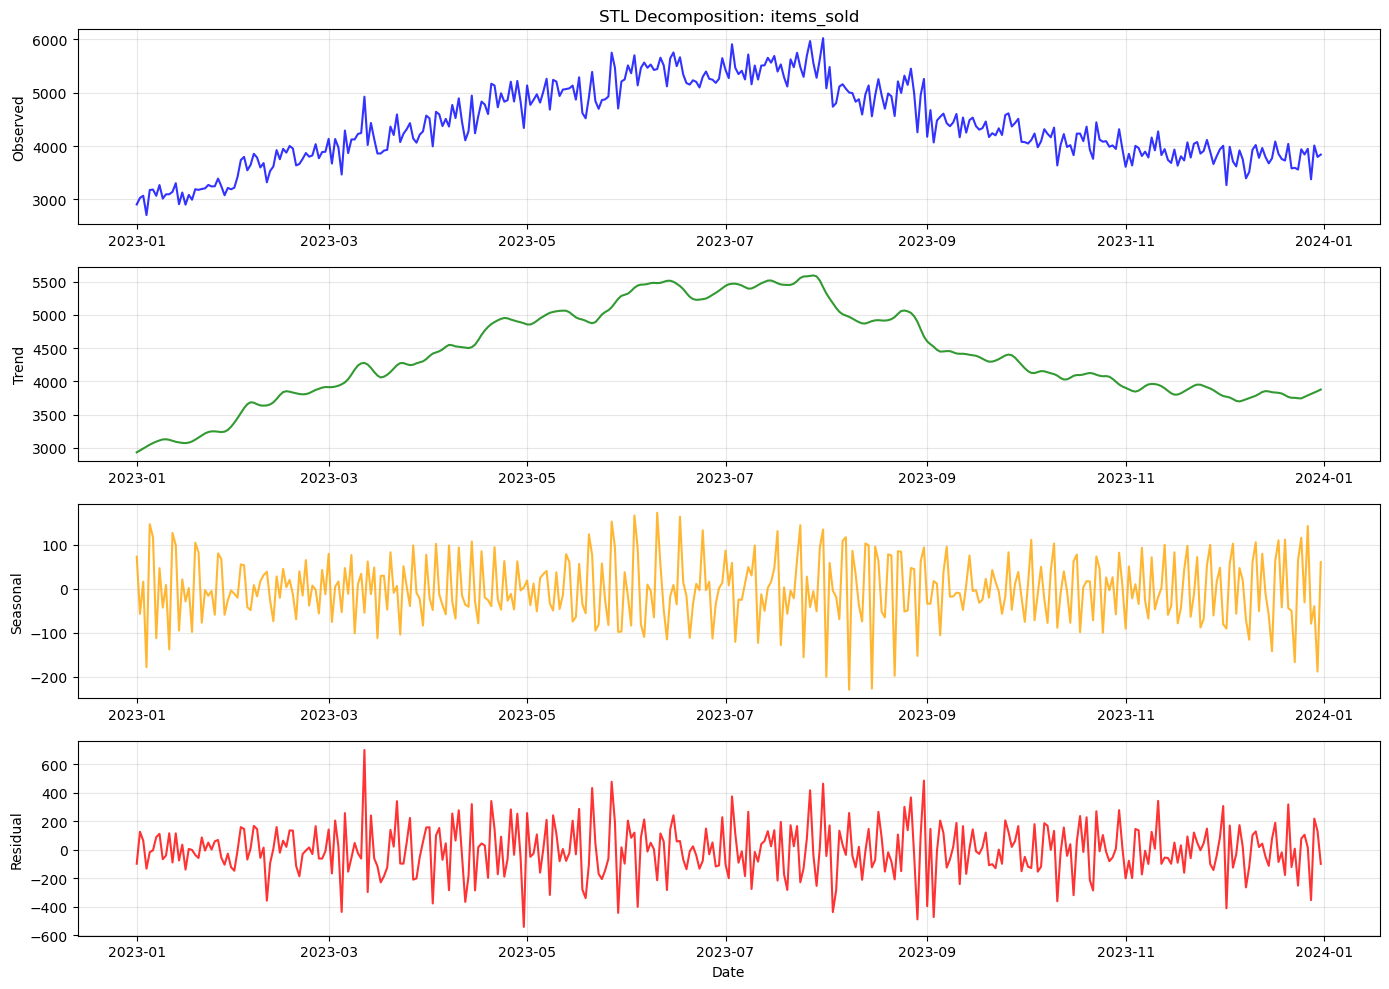

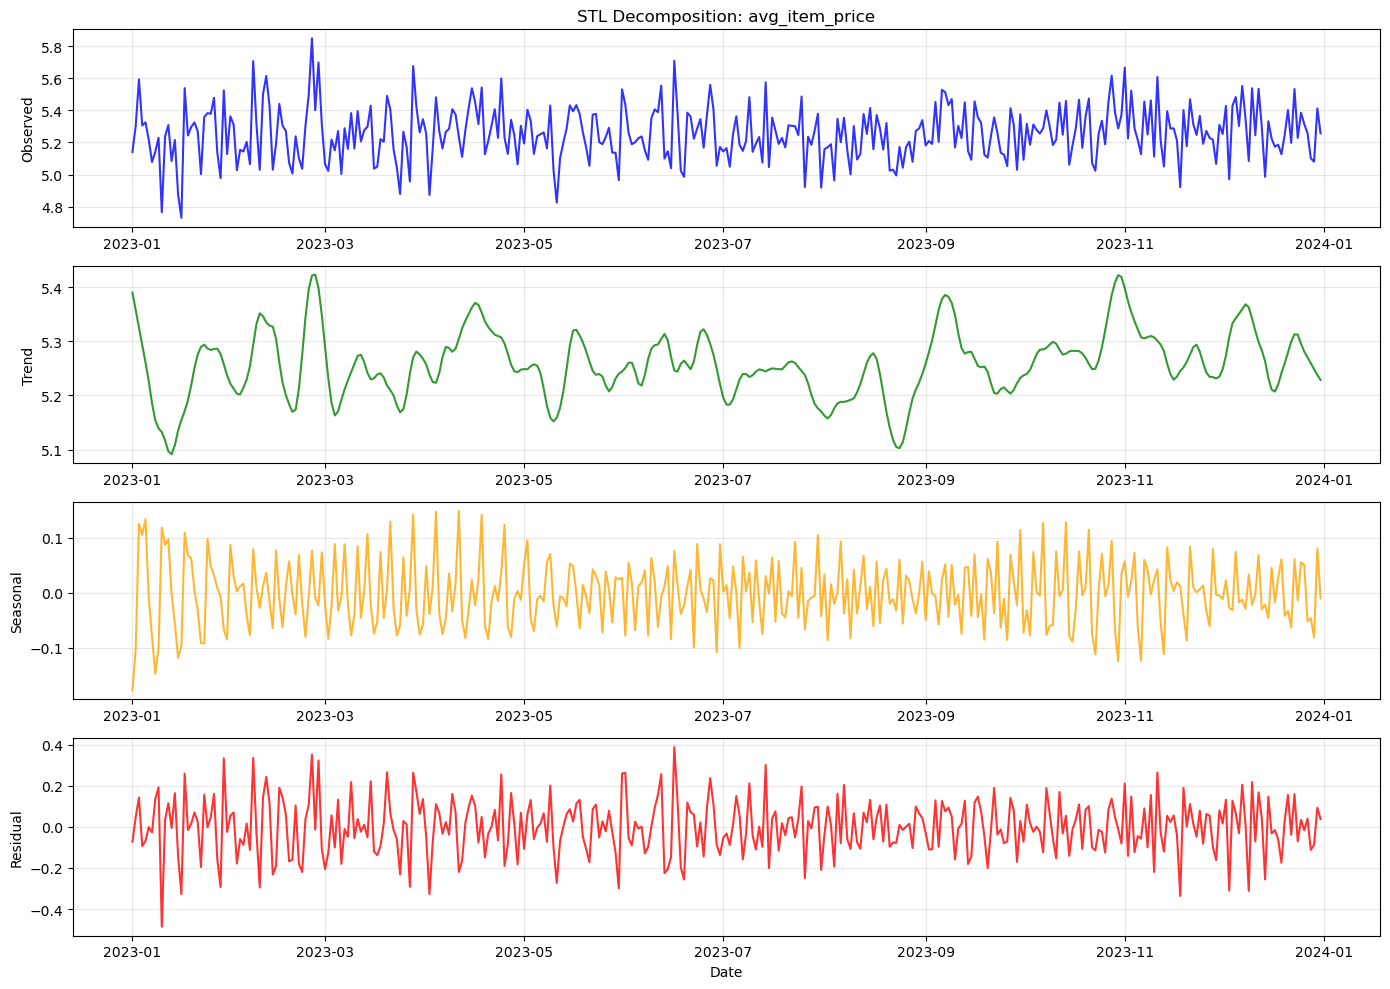

In [94]:

stl_results = {}

for metric in metrics:
    stl_results[metric] = perform_stl(data[metric])
    plot_stl(stl_results[metric], metric, data['date'])

In [95]:
# Применение ESD к остаткам STL
may_mask = (data['date'] >= '2023-05-01') & (data['date'] <= '2023-05-31')
results_stl_esd = {}
total_anomalies = 0

for metric in metrics:
    residuals = pd.Series(stl_results[metric].resid.values, index=data.index)
    residuals_may = residuals[may_mask]
    
    anomaly_indices = generalized_esd(residuals_may, max_anomalies=10)
    results_stl_esd[metric] = anomaly_indices
    total_anomalies += len(anomaly_indices)

answer_task_5 = total_anomalies
answer_task_5

0

In [96]:
# Анализ силы сезонности и тренда
seasonality_analysis = []

for metric in metrics:
    seasonal_strength = stl_results[metric].seasonal.std() / data[metric].std()
    trend_strength = stl_results[metric].trend.std() / data[metric].std()
    
    seasonality_analysis.append({
        'metric': metric,
        'seasonal_strength': round(seasonal_strength, 4),
        'trend_strength': round(trend_strength, 4),
        'has_seasonality': seasonal_strength > 0.1,
        'has_trend': trend_strength > 0.5
    })

pd.DataFrame(seasonality_analysis)

,metric,seasonal_strength,trend_strength,has_seasonality,has_trend
0,gmv,0.1091,0.9438,True,True
1,items_sold,0.0970,0.9585,False,True
2,avg_item_price,0.3512,0.3627,True,False


**Задание**: введите количество аномалий (сумма для всех метрик — целое число), полученное на остатках STL разложением и Generalized ESD.

STL вычленил паттерны Видим: gmv (тренд+сезонность), items_sold (только тренд), avg_item_price (сильная сезонность 0.35). ESD на остатках → 0 аномалий в мае. Все выбросы объяснились паттернами


---

#### 6. EWMA — 2 балла

1) Реализуйте метод [EWMA](https://www.itl.nist.gov/div898/handbook/pmc/section3/pmc324.htm) для каждой метрики:
- gmv;
- items_sold;
- avg_item_price.

При расчётах используйте экспоненциальное сглаживание λ = 0.2, доверительные границы μ ± L·σ, где L = 3. Стандартное отклонение вычисляйте на окне 28 дней и используйте функцию асимптотического приближения:

$$
\sigma_z(\infty) = \sigma \sqrt{\frac{\lambda}{2-\lambda}}
$$

Обратите внимание, что в pandas есть [встроенная функция экспоненциального сглаживания](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html).


2) Постройте графики: сглаженная метрика + границы контроля + выделенные аномалии.
3) Напишите, какой из подходов вам больше всего понравился для онлайн-мониторинга, а какой — для ретроспективного анализа, и почему. Тут нет правильного ответа :)

In [ ]:
# Функция детекции аномалий методом EWMA
def detect_anomalies_ewma(series, lambda_param=0.2, L=3, window_size=28):
    """
    EWMA с границами вокруг центральной линии (rolling mean), а не z_t.
    Формула из NIST: UCL/LCL = μ ± L·σ·sqrt(λ/(2-λ))
    """
    ewma_values = series.ewm(alpha=lambda_param, adjust=False).mean()

    
    rolling_mean = series.rolling(window=window_size).mean().shift(1)
    rolling_std = series.rolling(window=window_size).std().shift(1)

    asymptotic_factor = np.sqrt(lambda_param / (2 - lambda_param))
    sigma_ewma = rolling_std * asymptotic_factor

    result = pd.DataFrame({
        'original': series.values,
        'ewma': ewma_values,
        'center_line': rolling_mean,
        'std': rolling_std,
        'upper_bound': rolling_mean + L * sigma_ewma,
        'lower_bound': rolling_mean - L * sigma_ewma
    }, index=series.index)

    # Аномалия когда EWMA выходит за границы центральной линии
    result['is_anomaly'] = (
        (ewma_values > result['upper_bound']) |
        (ewma_values < result['lower_bound'])
    )

    return result

In [98]:
# Функция визуализации EWMA
def plot_ewma(df_result, metric_name, date_col, may_only=True):
    """Построение графика EWMA с центральной линией и границами."""
    mask = (date_col >= '2023-05-01') & (date_col <= '2023-05-31')
    plot_data = df_result[mask].copy() if may_only else df_result.copy()
    plot_dates = date_col[mask] if may_only else date_col
    
    plt.figure(figsize=(14, 6))
    plt.plot(plot_dates, plot_data['original'], 
             label=f'Original', color='lightblue', alpha=0.5, linewidth=1)
    plt.plot(plot_dates, plot_data['ewma'], 
             label=f'EWMA (λ=0.2)', color='blue', linewidth=2)
    plt.plot(plot_dates, plot_data['center_line'], 
             label='Center Line (μ)', color='green', linewidth=1.5, linestyle=':')
    plt.plot(plot_dates, plot_data['upper_bound'], '--', 
             label='UCL (μ + L·σ)', color='red', alpha=0.7)
    plt.plot(plot_dates, plot_data['lower_bound'], '--', 
             label='LCL (μ - L·σ)', color='red', alpha=0.7)
    
    anomalies = plot_data[plot_data['is_anomaly']]
    if len(anomalies) > 0:
        plt.scatter(plot_dates[plot_data['is_anomaly']], anomalies['ewma'],
                   color='red', s=100, zorder=5, 
                   label=f'Anomalies ({len(anomalies)})')
    
    plt.xlabel('Date')
    plt.ylabel(metric_name)
    plt.title(f'EWMA Anomaly Detection: {metric_name} (May 2023)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

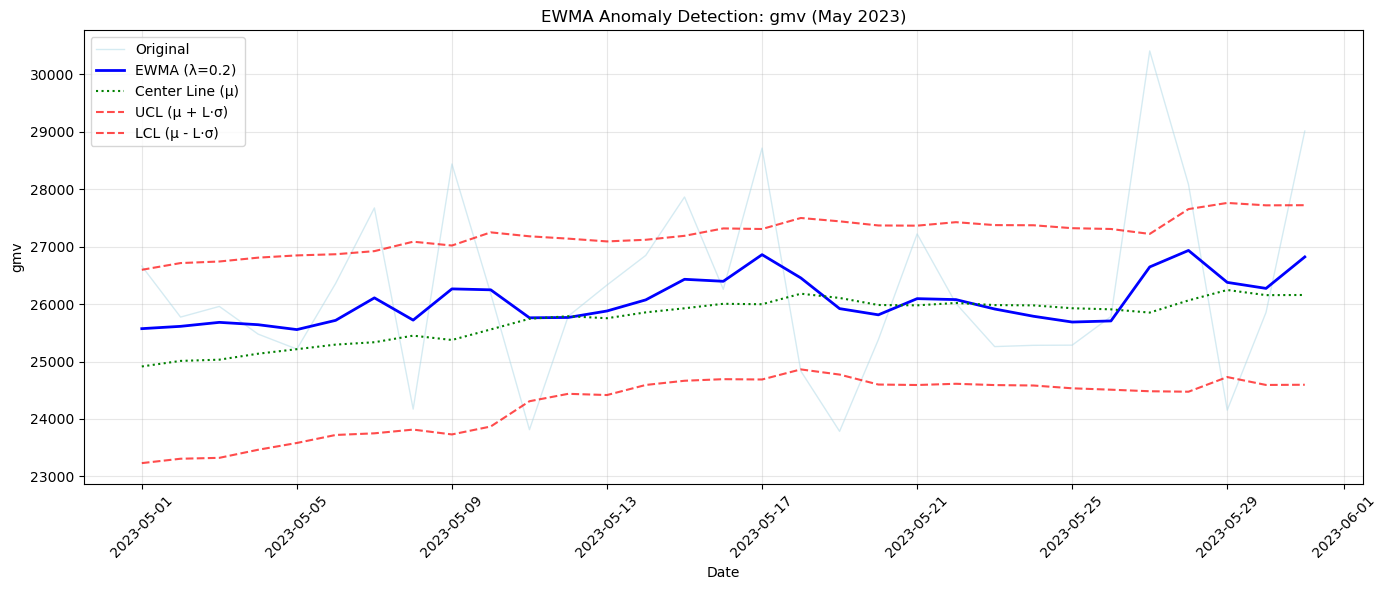

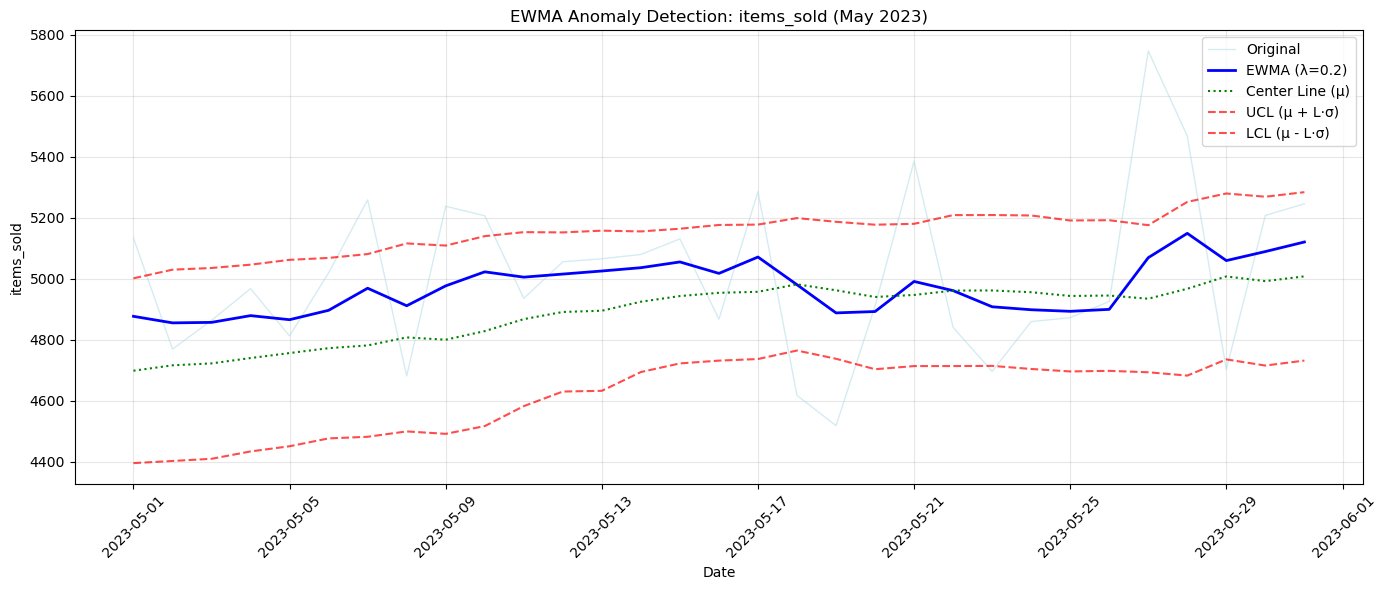

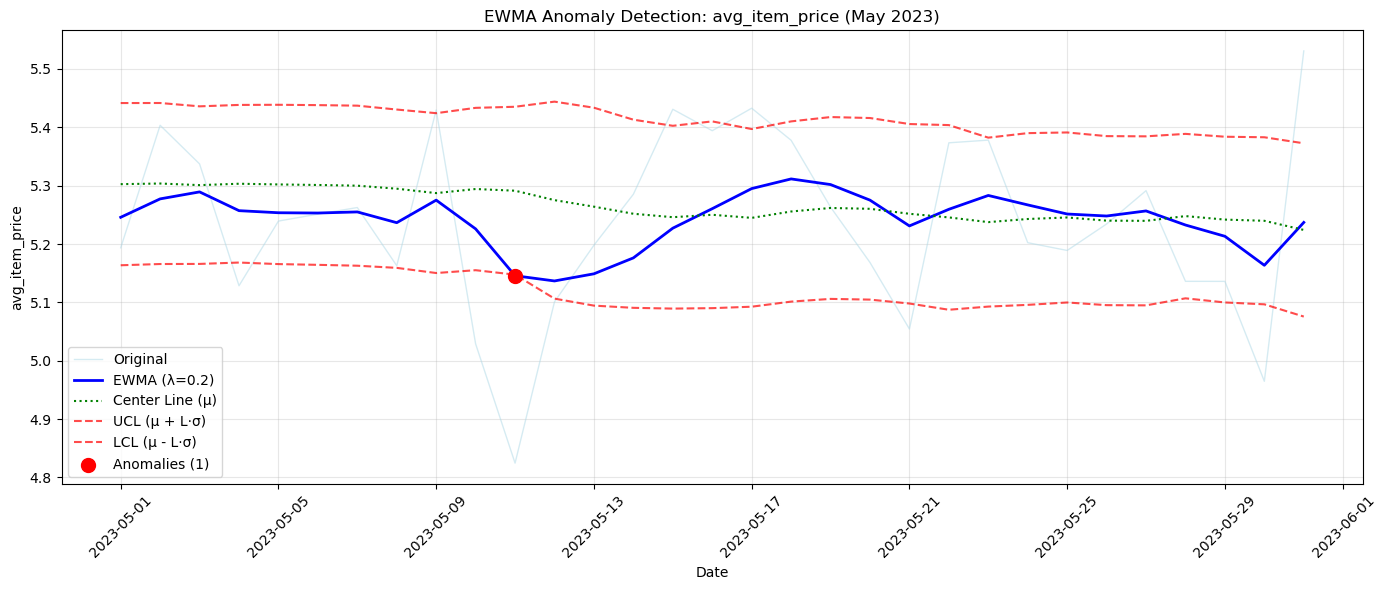

In [99]:

results_ewma = {}

for metric in metrics:
    results_ewma[metric] = detect_anomalies_ewma(data[metric])
    plot_ewma(results_ewma[metric], metric, data['date'])

In [ ]:

may_mask = (data['date'] >= '2023-05-01') & (data['date'] <= '2023-05-31')
ewma_avg_price_may = results_ewma['avg_item_price'][may_mask]
anomalies_ewma_price = ewma_avg_price_may[ewma_avg_price_may['is_anomaly']]

answer_task_6 = None
if len(anomalies_ewma_price) > 0:
    answer_task_6 = round(anomalies_ewma_price['ewma'].iloc[0], 2)
    
answer_task_6

5.15

**Задание**: введите сглаженное значение метрики avg_item_price, являющееся аномальным по методу EWMA. Ответ округлите до сотых.

EWMA реагирует на устойчивые сдвиги уровня, а не на разовые выбросы.